# Skyrmion relaxation

Relax an isolated Neel skyrmion in a single layer with interfacial DMI, then measure its topological charge and diameter. No demag.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from skyrmion_simulator.simulator.params_helper import make_params
from skyrmion_simulator.simulator.pulses import ConstantPulse
mu0 = 4.0e-7 * np.pi
from skyrmion_simulator.simulator.relaxation import relax
from skyrmion_simulator.simulator.initial_conditions import skyrmion_profile
from skyrmion_simulator.simulator.main import topological_charge
from skyrmion_simulator.simulator.analysis import skyrmion_diameter

In [2]:
A_ex, D, K_eff, Ms = 16.0e-12, 3.0e-3, 510.0e3, 8.755e5
a, nx = 1.0e-9, 64
K = K_eff + 0.5 * mu0 * Ms**2
p = make_params(nx=nx, ny=nx, a=a, A_ex=A_ex, D=D, K_top=K, K_bot=K,
                Ms=Ms, alpha=1.0, H_RKKY=0.0, H_ext=np.zeros(3),
                dt=5.0e-14, pulse=ConstantPulse(0.0))

Initial guess: a skyrmion profile with radius 10 nm and wall width 5.6 nm. `polarity=+1` puts the core at $m_z=-1$.

In [3]:
m0 = skyrmion_profile(nx, nx, a=a, R=10.0e-9, dw=5.6e-9, polarity=+1)
m, _, converged, n_steps, _, tau = relax(
    m0, None, p, None, max_steps=100000, tol_torque=1.0e-4,
    check_every=500)
print(f'converged={converged} after {n_steps} steps')

converged=True after 8000 steps


In [4]:
Q = topological_charge(m, a)
diam = skyrmion_diameter(m, a, +1)
print(f'topological charge Q = {Q:+.3f}')
print(f'diameter = {diam*1e9:.1f} nm')

topological charge Q = -0.989
diameter = 18.7 nm


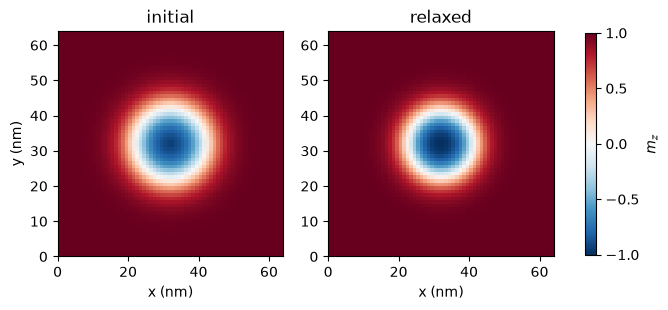

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(8, 3.6))
for ax, field, title in zip(axes, (m0, m), ('initial', 'relaxed')):
    im = ax.imshow(field[..., 2], origin='lower', cmap='RdBu_r',
                   vmin=-1, vmax=1, extent=[0, nx * a * 1e9] * 2)
    ax.set_title(title)
    ax.set_xlabel('x (nm)')
axes[0].set_ylabel('y (nm)')
fig.colorbar(im, ax=axes, label='$m_z$', shrink=0.8)
plt.show()